# MACHINE LEARNING - FINAL PROJECT
# By Samuel DIEUBENI Diffo Tchuenkam


### 1- Setup and Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("viridis")
%matplotlib inline

### 2- Load and clean data

In [18]:
df = pd.read_csv('all_seasons.csv')

df_clean = df.drop(columns=['Unnamed: 0', 'player_name', 'season'])

print("Dataset shape:", df_clean.shape)
print("\nTarget distribution:\n", df_clean['scoring_tier'].value_counts())

X = df_clean.drop('scoring_tier', axis=1)
y = df_clean['scoring_tier']

print("\nMissing values total:", X.isnull().sum().sum())

Dataset shape: (12844, 20)

Target distribution:
 scoring_tier
5_Reserve     4709
4_Bench       4099
3_Starter     2207
2_All-Star    1614
1_Elite        215
Name: count, dtype: int64

Missing values total: 1854


#### Target Distribution

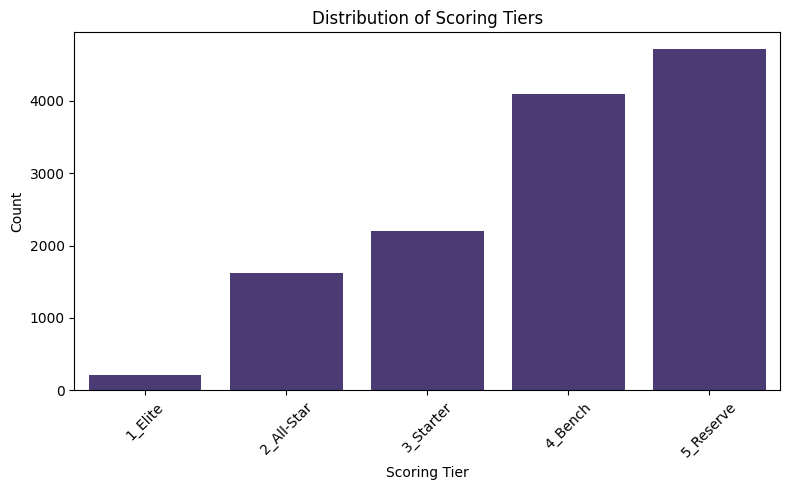

In [ ]:
plt.figure(figsize=(8, 5))
order = sorted(y.unique())
sns.countplot(x=y, order=order)
plt.title('Distribution of Scoring Tiers')
plt.xlabel('Scoring Tier')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figure1_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

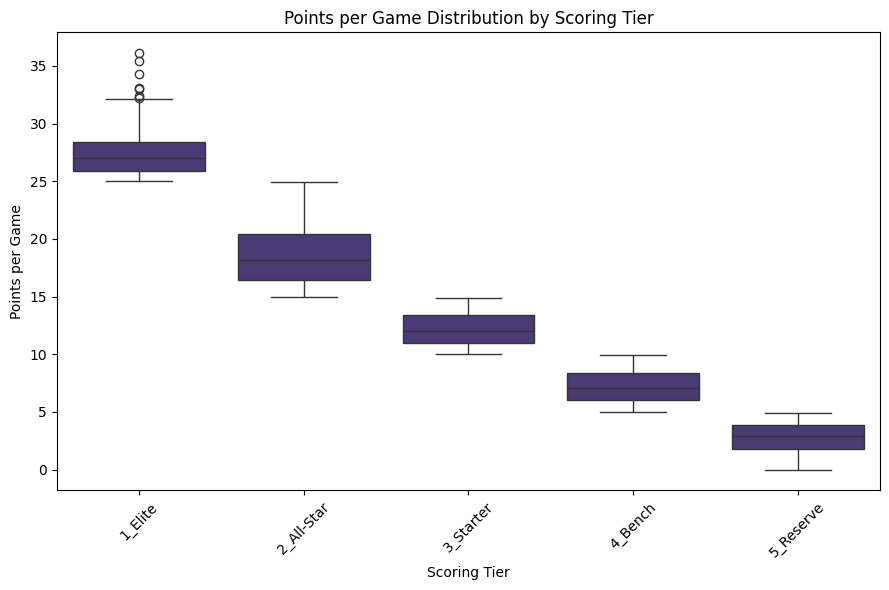

In [ ]:
df_viz = df_clean.copy()
df_viz['pts'] = df['pts']

plt.figure(figsize=(9, 6))
sns.boxplot(x='scoring_tier', y='pts', data=df_viz, order=order)
plt.title('Points per Game Distribution by Scoring Tier')
plt.xlabel('Scoring Tier')
plt.ylabel('Points per Game')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figure2_pts_by_tier.png', dpi=300, bbox_inches='tight')
plt.show()

### 3- Stratified Train / Validation / Test Split (70/15/15)

In [21]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42, stratify=y_train_full
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Train set: 8990 samples
Validation set: 1927 samples
Test set: 1927 samples


### 4- Preprocessing pipeline

In [22]:
numeric_features = ['age', 'player_height', 'player_weight', 'gp', 'reb', 'ast', 
                    'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct']

categorical_features = ['team_abbreviation', 'college', 'country', 'draft_round', 'draft_number']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

### 5- Fitting of all the 6 models

#### Logistic Regression

In [23]:
log_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_log = {'classifier__C': [0.01, 0.1, 1, 10, 100]}

grid_log = GridSearchCV(log_pipe, param_grid_log, cv=5, scoring='f1_macro', n_jobs=-1)
grid_log.fit(X_train, y_train)

print("Best Logistic params:", grid_log.best_params_)
print("Best CV F1-macro:", grid_log.best_score_)

Best Logistic params: {'classifier__C': 10}
Best CV F1-macro: 0.8299684495455594


#### Decision Tree

In [24]:
tree_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid_tree = {'classifier__max_depth': [3, 5, 8, 10, 15, None]}

grid_tree = GridSearchCV(tree_pipe, param_grid_tree, cv=5, scoring='f1_macro', n_jobs=-1)
grid_tree.fit(X_train, y_train)

print("Best Tree params:", grid_tree.best_params_)
print("Best CV F1-macro:", grid_tree.best_score_)

Best Tree params: {'classifier__max_depth': 15}
Best CV F1-macro: 0.7605629267098359


#### Support Vector Classifier

In [ ]:
svc_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, probability=False))
])

param_dist_svc = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 0.01],
    'classifier__kernel': ['rbf', 'linear']
}

random_svc = RandomizedSearchCV(
    svc_pipe, param_dist_svc, 
    n_iter=8,         
    cv=3,            
    scoring='f1_macro', 
    random_state=42, 
    n_jobs=-1
)

random_svc.fit(X_train, y_train)

print("Best SVC params:", random_svc.best_params_)
print("Best CV F1-macro:", random_svc.best_score_)

Best SVC params: {'classifier__kernel': 'rbf', 'classifier__gamma': 0.01, 'classifier__C': 10}
Best CV F1-macro: 0.8944657496168796


#### Random Forest Classifier

In [26]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [8, 12, 15, None]
}

grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best Random Forest params:", grid_rf.best_params_)
print("Best CV F1-macro:", grid_rf.best_score_)

Best Random Forest params: {'classifier__max_depth': None, 'classifier__n_estimators': 200}
Best CV F1-macro: 0.7617921368603453


#### Gradient Boosting Classifier

In [27]:
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gb_pipe.fit(X_train, y_train)

print("Gradient Boosting fitted with default parameters + early stopping potential")

Gradient Boosting fitted with default parameters + early stopping potential


#### Neural Network

In [ ]:
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_nn = le.fit_transform(y_train)
y_val_nn = le.transform(y_val)
y_test_nn = le.transform(y_test)

n_classes = len(le.classes_)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_prep.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    X_train_prep, y_train_nn,
    validation_data=(X_val_prep, y_val_nn),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test_prep, y_test_nn, verbose=0)
print(f"Neural Network Test Accuracy: {test_acc:.4f}")

Epoch 1/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6858 - loss: 0.7637 - val_accuracy: 0.8495 - val_loss: 0.4093
Epoch 2/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8386 - loss: 0.3985 - val_accuracy: 0.8729 - val_loss: 0.3000
Epoch 3/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8758 - loss: 0.3063 - val_accuracy: 0.8895 - val_loss: 0.2547
Epoch 4/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8991 - loss: 0.2575 - val_accuracy: 0.8988 - val_loss: 0.2328
Epoch 5/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9063 - loss: 0.2297 - val_accuracy: 0.9035 - val_loss: 0.2362
Epoch 6/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9200 - loss: 0.2084 - val_accuracy: 0.9014 - val_loss: 0.2340
Epoch 7/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9285 - loss: 0.1870 - val_accuracy: 0.9024 - val_loss: 0.2343
Epoch 8/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9304 - loss: 0.1760 - val_accu

### 6- Model Comparison Table & Test Evaluation

In [29]:
models = {
    'Logistic Regression': grid_log,
    'Decision Tree': grid_tree,
    'SVC': random_svc,
    'Random Forest': grid_rf,
    'Gradient Boosting': gb_pipe,
    'Neural Network': model
}

results = []

for name, m in models.items():
    if name == 'Neural Network':
        y_pred = np.argmax(model.predict(X_test_prep), axis=1)
        y_pred_labels = le.inverse_transform(y_pred)
        test_f1 = f1_score(y_test, y_pred_labels, average='macro')
        test_acc = accuracy_score(y_test, y_pred_labels)
        cv_score = test_acc  # NN doesn't have CV like others
        std = np.nan
    else:
        y_pred = m.predict(X_test)
        test_f1 = f1_score(y_test, y_pred, average='macro')
        test_acc = accuracy_score(y_test, y_pred)
        cv_score = m.best_score_ if hasattr(m, 'best_score_') else m.score(X_val, y_val)
        std = np.nan  # You can add std from cv_results_ if needed
    
    results.append({
        'Model': name,
        'Best Hyperparameters': m.best_params_ if hasattr(m, 'best_params_') else 'N/A (early stopping)',
        'CV F1-macro (mean)': round(cv_score, 4),
        'Test Accuracy': round(test_acc, 4),
        'Test F1-macro': round(test_f1, 4)
    })

results_df = pd.DataFrame(results)
print(results_df)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                 Model                               Best Hyperparameters  \
0  Logistic Regression                              {'classifier__C': 10}   
1        Decision Tree                      {'classifier__max_depth': 15}   
2                  SVC  {'classifier__kernel': 'rbf', 'classifier__gam...   
3        Random Forest  {'classifier__max_depth': None, 'classifier__n...   
4    Gradient Boosting                               N/A (early stopping)   
5       Neural Network                               N/A (early stopping)   

   CV F1-macro (mean)  Test Accuracy  Test F1-macro  
0              0.8300         0.8614         0.8414  
1              0.7606         0.7924         0.7476  
2              0.8945         0.9206         0.8974  
3              0.7618         0.7961         0.7535  
4              0.8480         0.8485         0.8077  
5              0.8978         0.8978         0.8571  


#### Confusion Matrix

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


<Figure size 1000x800 with 0 Axes>

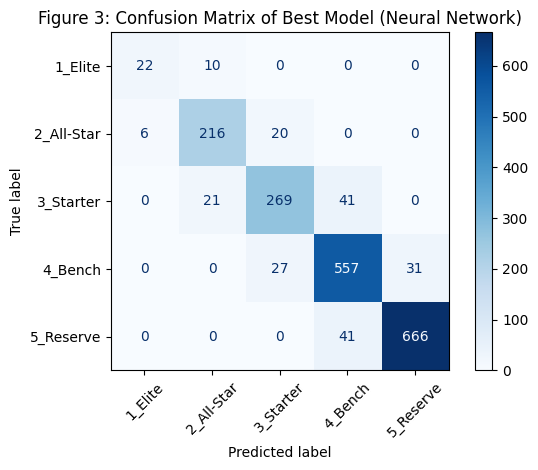

In [ ]:
y_pred_nn = np.argmax(model.predict(X_test_prep), axis=1)
y_pred_nn_labels = le.inverse_transform(y_pred_nn)

cm = confusion_matrix(y_test, y_pred_nn_labels, labels=le.classes_)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Figure 3: Confusion Matrix of Best Model (Neural Network)')
plt.tight_layout()
plt.savefig('figure3_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()